# Unemployment Analysis in India

## Overview

This project explores unemployment trends in India using unemployment-rate data from 2019–2020. The analysis focuses on overall trends, state-wise differences, rural vs urban unemployment, geographical regions, and the impact of the COVID-19 period.

The goal is to identify meaningful patterns in unemployment and understand how the labour market changed during the period covered by the datasets.

## Objectives

The main objectives of this analysis are:

- Analyze unemployment trends over time.
- Compare unemployment rates across Indian states.
- Compare unemployment between rural and urban areas.
- Examine the relationship between unemployment and labour participation.
- Investigate the impact of COVID-19 on unemployment.
- Compare unemployment trends across geographical regions.
- Identify key insights from the data.

## Dataset Overview

Two datasets are used in this project.

### Area-level unemployment data

This dataset contains unemployment information by state and area type, including unemployment rate, estimated employment, labour participation rate, and area classification such as Rural or Urban.

### Regional unemployment data

This dataset contains unemployment information along with geographical region, longitude, and latitude. It extends further into 2020 and is therefore useful for analyzing the COVID-19 shock and subsequent recovery.

## Tools & Technologies

- **Python** — Programming language
- **Pandas** — Data manipulation and analysis
- **NumPy** — Numerical operations
- **Matplotlib** — Data visualization
- **Seaborn** — Statistical visualization
- **Jupyter Notebook** — Interactive analysis environment

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


## 1. Data Loading

The datasets are loaded using Pandas. The Area-level dataset is used for state-wise, rural vs urban, and overall unemployment analysis, while the Regional dataset provides additional geographical information and extends further into 2020.

In [2]:
# Load the datasets

df_area = pd.read_csv("data/Unemployment in India.csv")
df_region = pd.read_csv("data/Unemployment_Rate_upto_11_2020.csv")

print("Area dataset shape:", df_area.shape)
print("Region dataset shape:", df_region.shape) 

Area dataset shape: (768, 7)
Region dataset shape: (267, 9)


In [3]:
# Display the first 5 rows of each dataset

print("AREA DATASET")
display(df_area.head())

print("\nREGION DATASET")
display(df_region.head())

AREA DATASET


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



REGION DATASET


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
# Clean column names

df_area.columns = df_area.columns.str.strip()
df_region.columns = df_region.columns.str.strip()

# Convert date columns to datetime format

df_area['Date'] = pd.to_datetime(df_area['Date'], dayfirst=True)
df_region['Date'] = pd.to_datetime(df_region['Date'], dayfirst=True)

# Check the cleaned column names

print("Area dataset columns:")
print(df_area.columns.tolist())

print("\nRegion dataset columns:")
print(df_region.columns.tolist())

Area dataset columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Region dataset columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


## 2. Data Cleaning

Before performing the analysis, the datasets were checked for missing values and duplicate records.

The Area dataset contained 28 completely empty rows, which were removed. After cleaning, it contained 740 valid observations.

The Regional dataset contained no missing values and no duplicate records.

This ensures that the subsequent analysis is based on valid and consistent observations.

In [5]:
# Check for missing values

print("Missing values in Area dataset:")
print(df_area.isnull().sum())

print("\nMissing values in Region dataset:")
print(df_region.isnull().sum())

Missing values in Area dataset:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Missing values in Region dataset:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [6]:
# Remove completely empty rows

df_area = df_area.dropna(how='all')

print("Area dataset shape after removing empty rows:", df_area.shape)
print("Region dataset shape:", df_region.shape)

Area dataset shape after removing empty rows: (740, 7)
Region dataset shape: (267, 9)


In [7]:
# Check for duplicate rows

print("Duplicate rows in Area dataset:", df_area.duplicated().sum())
print("Duplicate rows in Region dataset:", df_region.duplicated().sum())

Duplicate rows in Area dataset: 0
Duplicate rows in Region dataset: 0


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution, trends, and patterns present in the unemployment data.

In [8]:
# Statistical summary of the datasets

print("AREA DATASET - STATISTICAL SUMMARY")
display(df_area.describe())

print("\nREGION DATASET - STATISTICAL SUMMARY")
display(df_region.describe())

AREA DATASET - STATISTICAL SUMMARY


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094



REGION DATASET - STATISTICAL SUMMARY


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [9]:
# Check the time period covered by each dataset

print("Area dataset:")
print("Start date:", df_area['Date'].min())
print("End date:", df_area['Date'].max())

print("\nRegion dataset:")
print("Start date:", df_region['Date'].min())
print("End date:", df_region['Date'].max())

Area dataset:
Start date: 2019-05-31 00:00:00
End date: 2020-06-30 00:00:00

Region dataset:
Start date: 2020-01-31 00:00:00
End date: 2020-10-31 00:00:00


### 3.1 Overall Unemployment Trend

The monthly average unemployment rate is analyzed to identify major changes over time.

The unemployment rate remained relatively stable during 2019 and early 2020, before rising sharply during April and May 2020. This period corresponds with the major disruption associated with the COVID-19 pandemic.

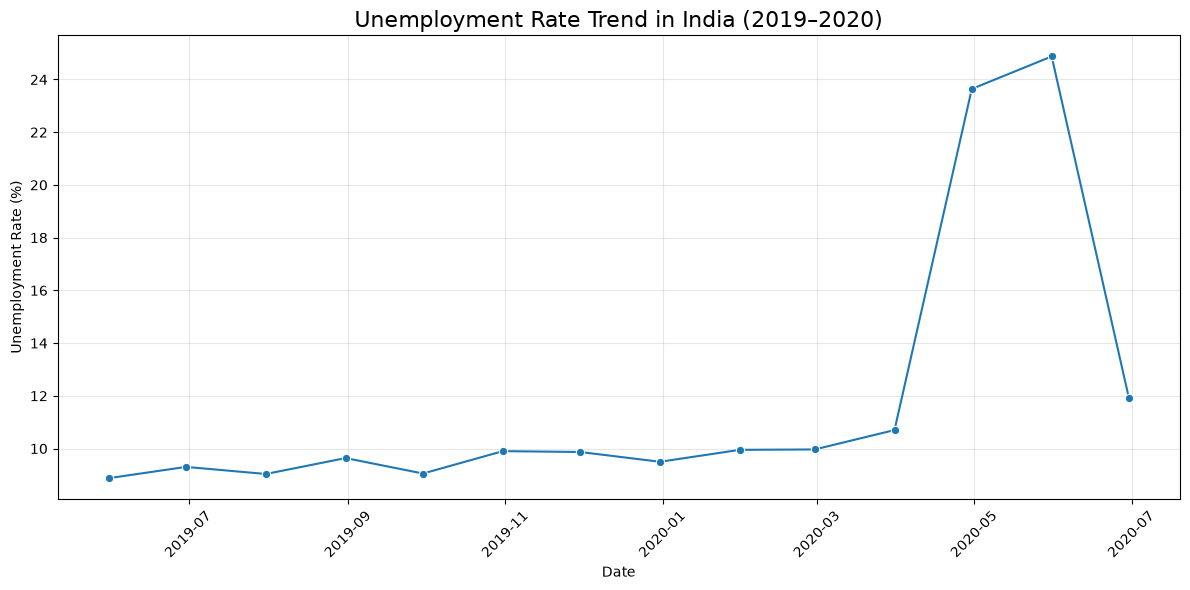

In [10]:
# Monthly unemployment trend in India

monthly_unemployment = (
    df_area.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_unemployment,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    marker='o'
)

plt.title('Unemployment Rate Trend in India (2019–2020)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [11]:
# Compare unemployment before and during the COVID-19 period

pre_covid = df_area[
    df_area['Date'] < '2020-04-01'
]['Estimated Unemployment Rate (%)'].mean()

covid_period = df_area[
    df_area['Date'] >= '2020-04-01'
]['Estimated Unemployment Rate (%)'].mean()

increase = ((covid_period - pre_covid) / pre_covid) * 100

print(f"Average unemployment rate before April 2020: {pre_covid:.2f}%")
print(f"Average unemployment rate from April 2020 onward: {covid_period:.2f}%")
print(f"Percentage increase: {increase:.2f}%")

Average unemployment rate before April 2020: 9.61%
Average unemployment rate from April 2020 onward: 20.19%
Percentage increase: 110.03%


### 3.2 State-wise Unemployment Analysis

The average unemployment rate is calculated for each state to identify states with relatively higher and lower unemployment levels.

The analysis shows considerable variation across states. Tripura recorded the highest average unemployment rate at approximately 28.35%, followed by Haryana at 26.28%.

In contrast, Meghalaya recorded the lowest average unemployment rate at approximately 4.80%.

In [12]:
# Average unemployment rate by state

state_unemployment = (
    df_area.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 states with highest average unemployment rate:")
display(state_unemployment.head(10))

Top 10 states with highest average unemployment rate:


Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

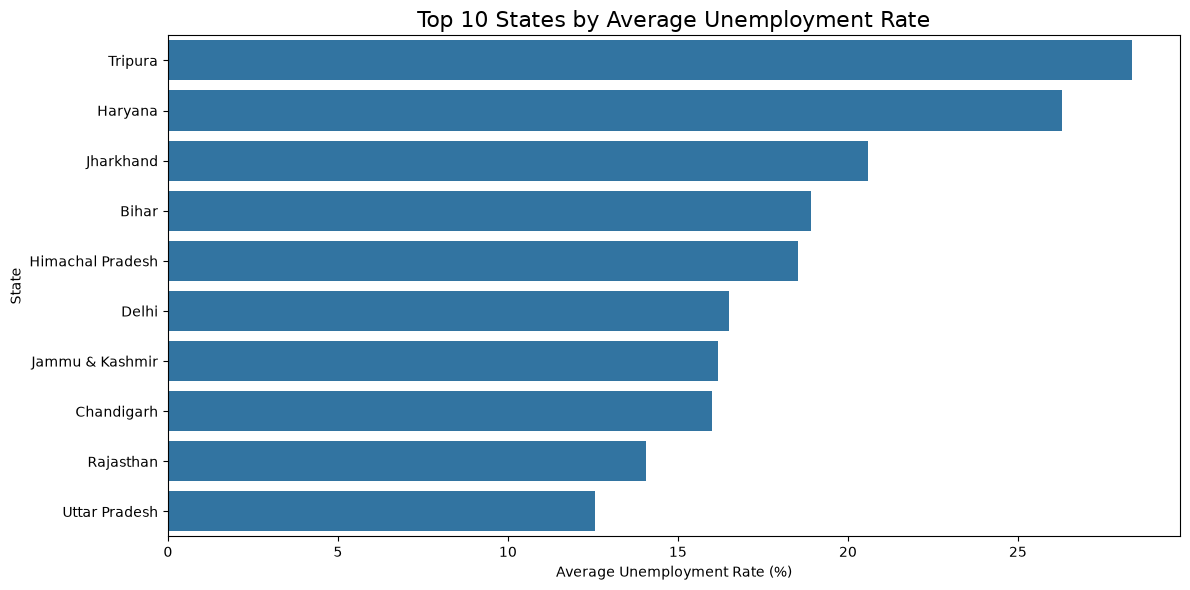

In [13]:
# Visualize top 10 states by average unemployment rate

top_10_states = state_unemployment.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index
)

plt.title('Top 10 States by Average Unemployment Rate', fontsize=16)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()

plt.show()

### States with Lowest Average Unemployment

The lowest unemployment rates were observed in Meghalaya, Odisha, Assam, Uttarakhand, and Gujarat.

This comparison highlights the substantial variation in unemployment across different states during the period covered by the dataset.

In [14]:
# Top 10 states with the lowest average unemployment rate

print("Top 10 states with lowest average unemployment rate:")
display(state_unemployment.sort_values().head(10))

Top 10 states with lowest average unemployment rate:


Region
Meghalaya         4.798889
Odisha            5.657857
Assam             6.428077
Uttarakhand       6.582963
Gujarat           6.663929
Karnataka         6.676071
Sikkim            7.249412
Madhya Pradesh    7.406429
Andhra Pradesh    7.477143
Maharashtra       7.557500
Name: Estimated Unemployment Rate (%), dtype: float64

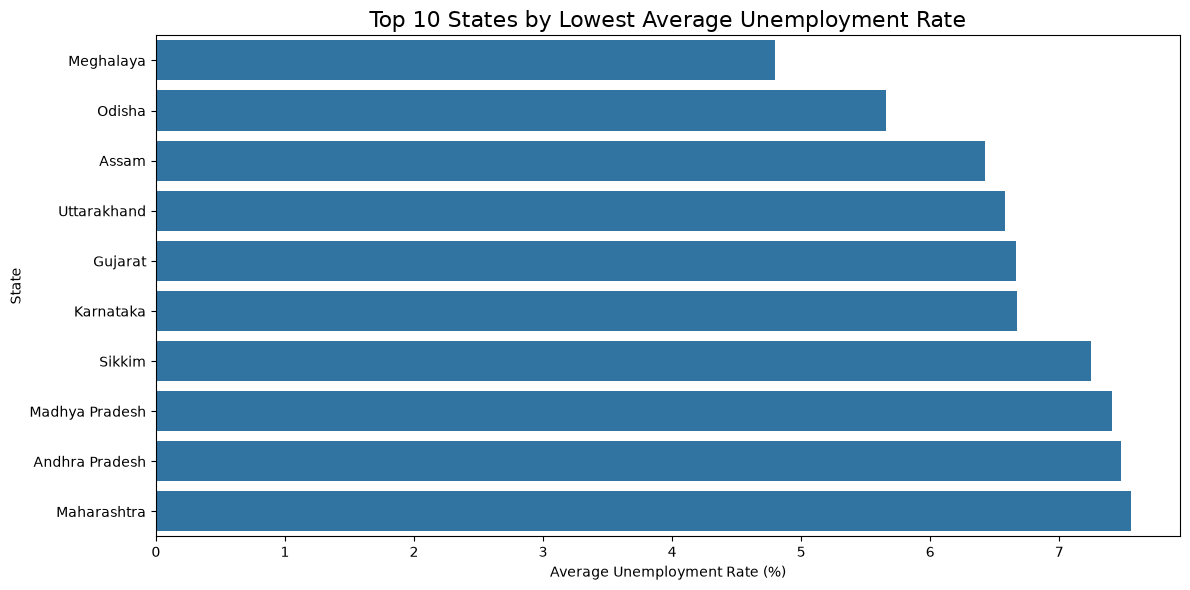

In [15]:
# Visualize top 10 states with lowest unemployment rate

lowest_10_states = state_unemployment.sort_values().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=lowest_10_states.values,
    y=lowest_10_states.index
)

plt.title('Top 10 States by Lowest Average Unemployment Rate', fontsize=16)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()

plt.show()

### 3.3 Rural vs Urban Unemployment

The unemployment rate is compared between rural and urban areas.

Urban areas recorded an average unemployment rate of 13.67%, compared with 10.32% in rural areas. This represents a difference of approximately 3.34 percentage points.

The result indicates that unemployment patterns differed noticeably between urban and rural areas during the period covered by the dataset.

In [16]:
# Compare average unemployment in Rural and Urban areas

area_unemployment = (
    df_area.groupby('Area')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print("Average unemployment rate by area:")
display(area_unemployment)

Average unemployment rate by area:


Area
Urban    13.166614
Rural    10.324791
Name: Estimated Unemployment Rate (%), dtype: float64

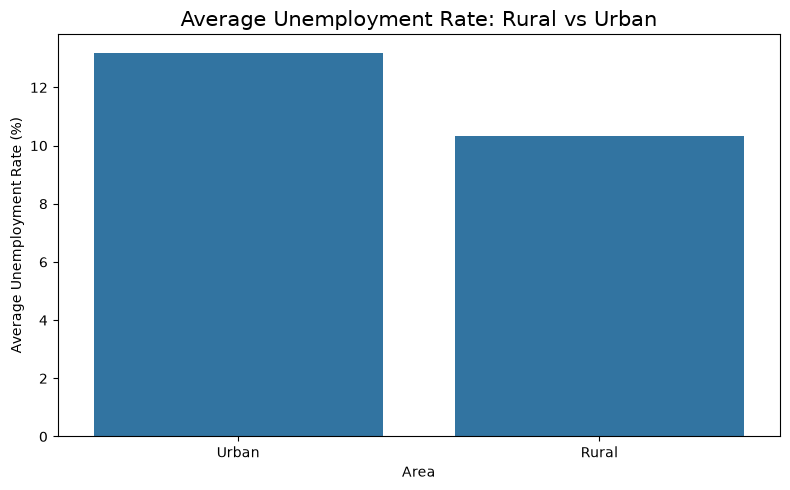

In [17]:
# Visualize Rural vs Urban unemployment

plt.figure(figsize=(8, 5))

sns.barplot(
    x=area_unemployment.index,
    y=area_unemployment.values
)

plt.title('Average Unemployment Rate: Rural vs Urban', fontsize=15)
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()

plt.show()

### 3.4 Unemployment and Labour Participation

The relationship between the unemployment rate and labour participation rate is examined using correlation analysis and a scatter plot.

The correlation coefficient is approximately 0.003, indicating virtually no linear relationship between the two variables in this dataset.

The scatter plot also shows that the observations are widely distributed rather than following a clear linear pattern.

In [18]:
# Analyze relationship between unemployment and labour participation

correlation = df_area[
    ['Estimated Unemployment Rate (%)',
     'Estimated Labour Participation Rate (%)']
].corr()

print("Correlation between unemployment rate and labour participation rate:")
display(correlation)

Correlation between unemployment rate and labour participation rate:


,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,0.002558
Estimated Labour Participation Rate (%),0.002558,1.000000


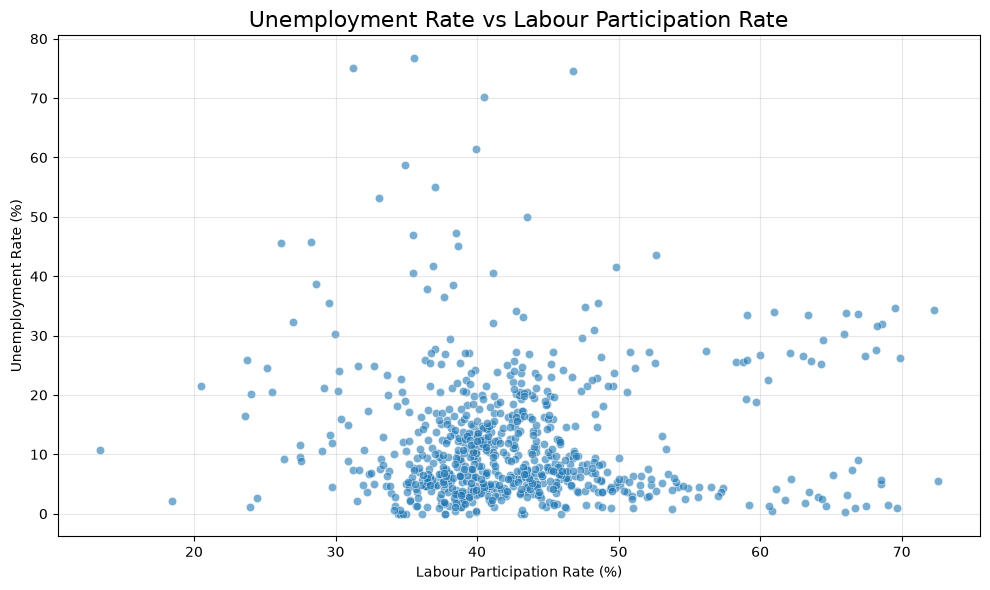

In [19]:
# Scatter plot: Unemployment vs Labour Participation

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_area,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    alpha=0.6
)

plt.title('Unemployment Rate vs Labour Participation Rate', fontsize=16)
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [20]:
# Calculate monthly average unemployment rate

monthly_unemployment = (
    df_area.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

display(monthly_unemployment)

,Date,Estimated Unemployment Rate (%)
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731
5,2019-10-31,9.900909
6,2019-11-30,9.868364
7,2019-12-31,9.497358
8,2020-01-31,9.950755
9,2020-02-29,9.964717


In [21]:
# Identify the peak unemployment month

peak_row = monthly_unemployment.loc[
    monthly_unemployment['Estimated Unemployment Rate (%)'].idxmax()
]

print("Peak unemployment month:")
print("Date:", peak_row['Date'].strftime('%B %Y'))
print("Unemployment Rate:", 
      f"{peak_row['Estimated Unemployment Rate (%)']:.2f}%")

Peak unemployment month:
Date: May 2020
Unemployment Rate: 24.88%


In [22]:
# Compare different periods

pre_covid = df_area[
    df_area['Date'] < '2020-04-01'
]['Estimated Unemployment Rate (%)'].mean()

covid_onset = df_area[
    (df_area['Date'] >= '2020-04-01') &
    (df_area['Date'] < '2020-05-01')
]['Estimated Unemployment Rate (%)'].mean()

peak_period = df_area[
    (df_area['Date'] >= '2020-05-01') &
    (df_area['Date'] < '2020-07-01')
]['Estimated Unemployment Rate (%)'].mean()

post_peak = df_area[
    df_area['Date'] >= '2020-07-01'
]['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-COVID average: {pre_covid:.2f}%")
print(f"April 2020 average: {covid_onset:.2f}%")
print(f"May-June 2020 average: {peak_period:.2f}%")
print(f"July 2020 average: {post_peak:.2f}%")

Pre-COVID average: 9.61%
April 2020 average: 23.64%
May-June 2020 average: 18.45%
July 2020 average: nan%


## 4. COVID-19 Impact Analysis

The COVID-19 period is analyzed separately because the data shows a sharp change in unemployment during 2020.

The Regional dataset extends from January to October 2020, allowing the analysis to examine the initial shock as well as the subsequent decline in unemployment.

In [23]:
# Monthly unemployment trend using the Region dataset

region_monthly = (
    df_region.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

display(region_monthly)

,Date,Estimated Unemployment Rate (%)
0,2020-01-31,9.196538
1,2020-02-29,9.266154
2,2020-03-31,10.782593
3,2020-04-30,22.236154
4,2020-05-31,23.244444
5,2020-06-30,10.911111
6,2020-07-31,9.834444
7,2020-08-31,10.313333
8,2020-09-30,8.705926
9,2020-10-31,8.026296


### 4.1 COVID-19 Unemployment Trend

Unemployment remained around 9–11% during January to March 2020 before increasing sharply in April and May.

The unemployment rate reached a peak of 23.24% in May 2020. After the peak, unemployment declined considerably, reaching 8.03% by October 2020.

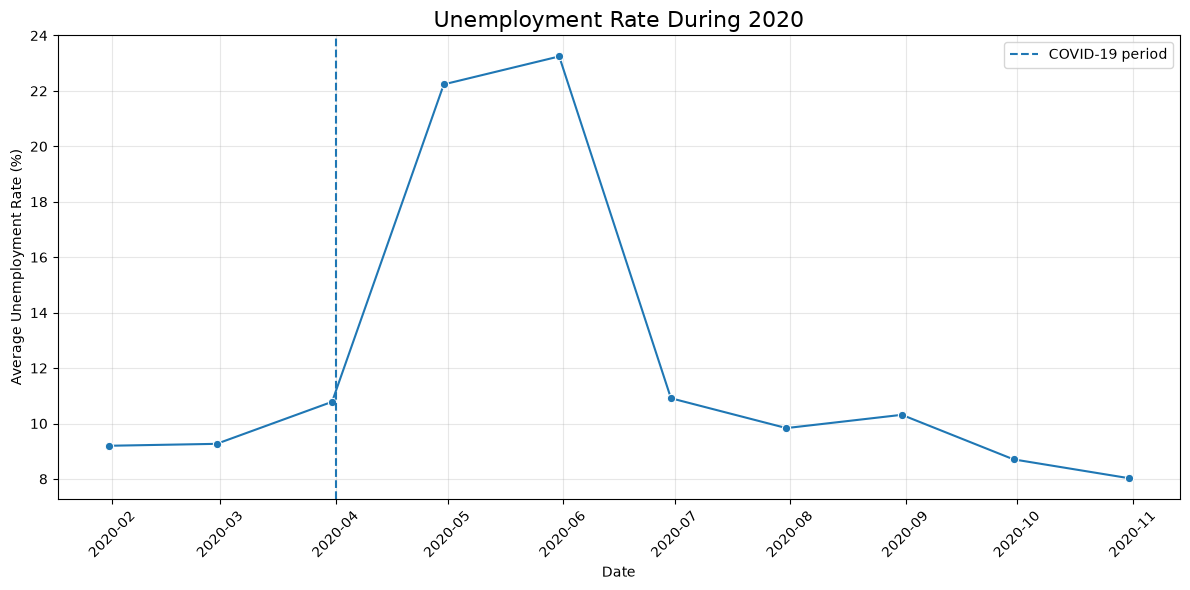

In [24]:
# COVID-19 unemployment trend: January to October 2020

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=region_monthly,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    marker='o'
)

plt.axvline(
    pd.Timestamp('2020-04-01'),
    linestyle='--',
    label='COVID-19 period'
)

plt.title('Unemployment Rate During 2020', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
# Calculate the COVID-19 unemployment shock

march_rate = region_monthly.loc[
    region_monthly['Date'] == '2020-03-31',
    'Estimated Unemployment Rate (%)'
].iloc[0]

may_rate = region_monthly.loc[
    region_monthly['Date'] == '2020-05-31',
    'Estimated Unemployment Rate (%)'
].iloc[0]

increase_percent = ((may_rate - march_rate) / march_rate) * 100

print(f"March 2020 unemployment rate: {march_rate:.2f}%")
print(f"May 2020 unemployment rate: {may_rate:.2f}%")
print(f"Increase from March to May: {increase_percent:.2f}%")

March 2020 unemployment rate: 10.78%
May 2020 unemployment rate: 23.24%
Increase from March to May: 115.57%


In [26]:
# Calculate recovery after the May 2020 peak

october_rate = region_monthly.loc[
    region_monthly['Date'] == '2020-10-31',
    'Estimated Unemployment Rate (%)'
].iloc[0]

recovery_percent = ((may_rate - october_rate) / may_rate) * 100

print(f"May 2020 peak: {may_rate:.2f}%")
print(f"October 2020 unemployment rate: {october_rate:.2f}%")
print(f"Reduction from May to October: {recovery_percent:.2f}%")

May 2020 peak: 23.24%
October 2020 unemployment rate: 8.03%
Reduction from May to October: 65.47%


In [27]:
# Average unemployment rate by geographical region

regional_unemployment = (
    df_region.groupby('Region.1')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print("Average unemployment rate by geographical region:")
display(regional_unemployment)

Average unemployment rate by geographical region:


Region.1
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate (%), dtype: float64

### 4.2 Geographical Regional Analysis

The average unemployment rate is compared across the geographical regions represented in the dataset.

The North recorded the highest average unemployment rate at approximately 15.86%, while the West recorded the lowest at approximately 8.23%.

This demonstrates considerable regional variation in unemployment during 2020.

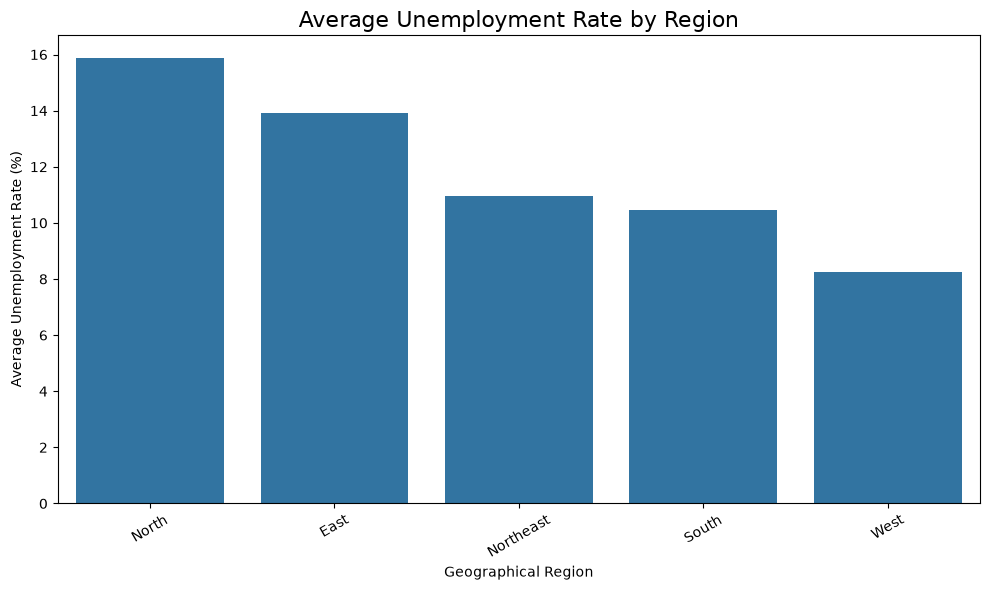

In [28]:
# Visualize unemployment by geographical region

plt.figure(figsize=(10, 6))

sns.barplot(
    x=regional_unemployment.index,
    y=regional_unemployment.values
)

plt.title('Average Unemployment Rate by Region', fontsize=16)
plt.xlabel('Geographical Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [29]:
# Compare regional unemployment before and during the COVID peak

regional_covid = df_region[
    df_region['Date'].isin([
        pd.Timestamp('2020-03-31'),
        pd.Timestamp('2020-05-31')
    ])
].groupby(
    ['Region.1', 'Date']
)['Estimated Unemployment Rate (%)'].mean().unstack()

regional_covid.columns = ['March 2020', 'May 2020']

regional_covid['Increase (%)'] = (
    (regional_covid['May 2020'] - regional_covid['March 2020'])
    / regional_covid['March 2020']
) * 100

display(regional_covid.sort_values('Increase (%)', ascending=False))

,March 2020,May 2020,Increase (%)
Region.1,,,
South,5.268333,26.888333,410.376463
East,10.915000,33.502500,206.939991
West,5.492000,16.260000,196.067007
North,16.066250,23.683750,47.413055
Northeast,14.967500,15.372500,2.705863


### 4.3 Regional Impact of COVID-19

The change in unemployment between March and May 2020 is compared across geographical regions.

The South experienced the largest relative increase of approximately 410.38%, followed by the East at 206.94% and the West at 196.07%.

However, percentage increases should be interpreted alongside the starting unemployment rate. The East recorded the highest unemployment rate in May 2020 at approximately 33.50%.

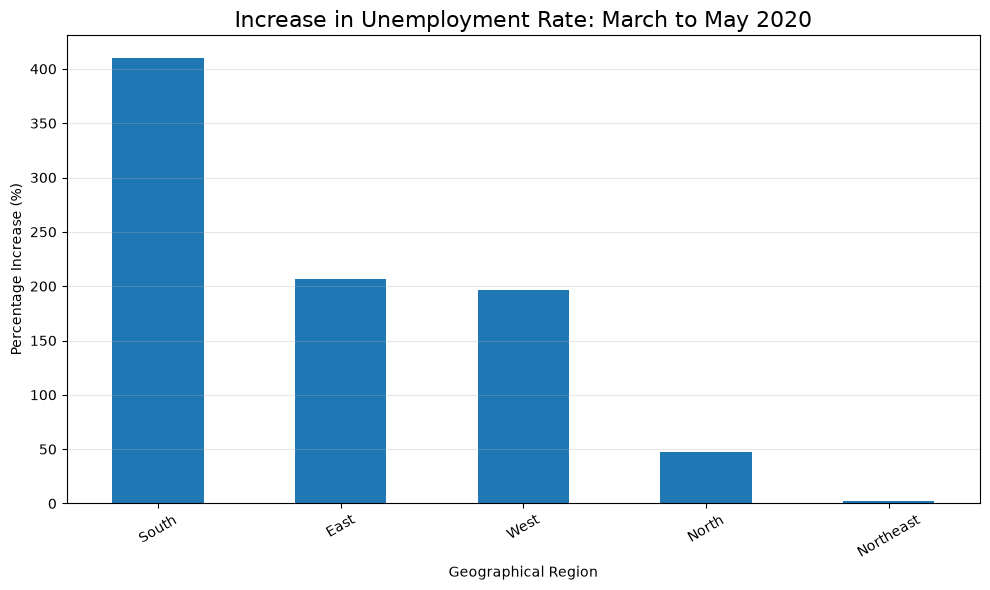

In [30]:
# Visualize regional COVID-19 impact

plt.figure(figsize=(10, 6))

regional_covid['Increase (%)'].sort_values(ascending=False).plot(
    kind='bar'
)

plt.title('Increase in Unemployment Rate: March to May 2020', fontsize=16)
plt.xlabel('Geographical Region')
plt.ylabel('Percentage Increase (%)')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [31]:
# Calculate monthly unemployment and labour participation rates

monthly_indicators = (
    df_region.groupby('Date')[
        ['Estimated Unemployment Rate (%)',
         'Estimated Labour Participation Rate (%)']
    ]
    .mean()
    .reset_index()
)

display(monthly_indicators)

,Date,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%)
0,2020-01-31,9.196538,44.626538
1,2020-02-29,9.266154,44.180769
2,2020-03-31,10.782593,43.746667
3,2020-04-30,22.236154,35.297308
4,2020-05-31,23.244444,39.647778
5,2020-06-30,10.911111,41.203333
6,2020-07-31,9.834444,42.274815
7,2020-08-31,10.313333,42.390741
8,2020-09-30,8.705926,41.974444
9,2020-10-31,8.026296,41.438519


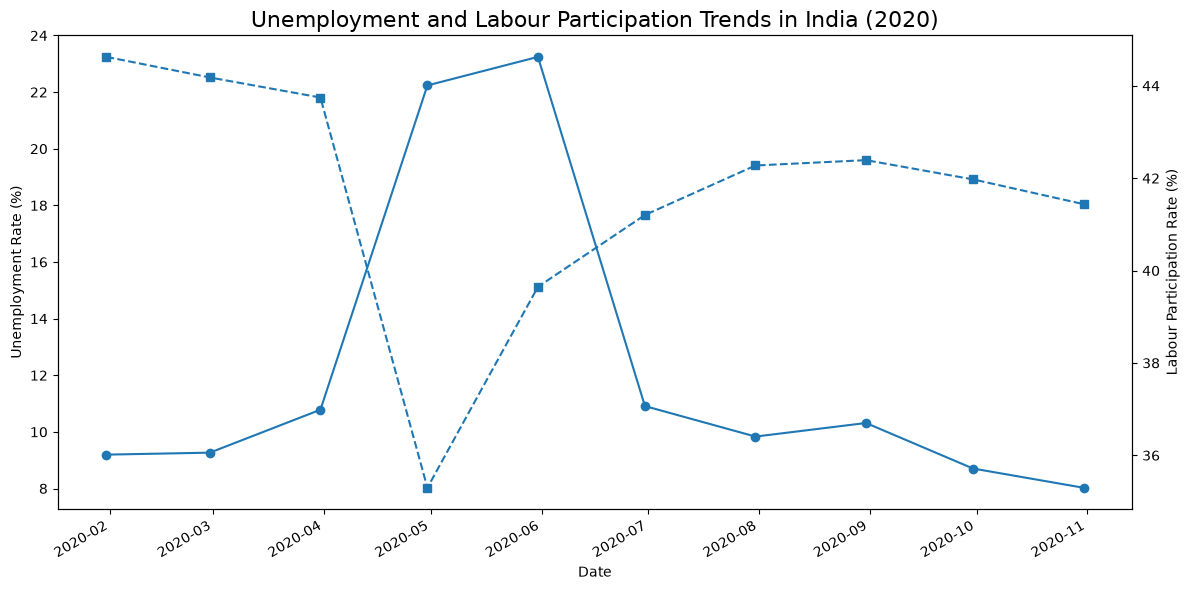

In [32]:
# Plot unemployment and labour participation trends

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    monthly_indicators['Date'],
    monthly_indicators['Estimated Unemployment Rate (%)'],
    marker='o',
    label='Unemployment Rate (%)'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Unemployment Rate (%)')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()

ax2.plot(
    monthly_indicators['Date'],
    monthly_indicators['Estimated Labour Participation Rate (%)'],
    marker='s',
    linestyle='--',
    label='Labour Participation Rate (%)'
)

ax2.set_ylabel('Labour Participation Rate (%)')
ax2.tick_params(axis='y')

plt.title(
    'Unemployment and Labour Participation Trends in India (2020)',
    fontsize=16
)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## 5. Key Findings

The major findings from the analysis are:

- India's unemployment rate increased sharply during the COVID-19 period.
- The unemployment rate increased from 10.78% in March 2020 to 23.24% in May 2020, representing a 115.57% increase.
- By October 2020, unemployment had fallen to 8.03%, representing an approximately 65.5% reduction from the May peak.
- Urban areas recorded a higher average unemployment rate (13.67%) than rural areas (10.32%).
- Tripura had the highest average unemployment rate among the states analyzed, at approximately 28.35%.
- Meghalaya had the lowest average unemployment rate, at approximately 4.80%.
- The North recorded the highest average unemployment rate among the geographical regions, while the West recorded the lowest.
- The correlation between unemployment and labour participation was approximately 0.003, indicating virtually no linear relationship in this dataset.

## 6. Conclusion

This analysis demonstrates significant variation in unemployment across states, geographical regions, and rural and urban areas in India.

The most prominent pattern was the sharp increase in unemployment during April and May 2020, followed by a substantial decline during the following months. The analysis also highlights differences in unemployment levels across regions and states.

Overall, the project demonstrates how exploratory data analysis and visualization can be used to identify important patterns and understand changes in India's unemployment landscape during 2019–2020.